In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('./data/processed/processed_file.csv', encoding='utf-8-sig')

# Первичный осмотр
print(f"📊 Данные: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"📅 Период: {df['Дата заказа'].min()} — {df['Дата заказа'].max()}")
print(f"🏪 Магазины: {df['Магазин'].unique()}")
print(f"📄 Чеков: {df['Файл'].nunique()}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nПропуски:\n{df.isnull().sum()}")

📊 Данные: 2173 строк, 9 колонок
📅 Период: 2024-11-15 20:42:46 — 2026-05-22 12:15:39
🏪 Магазины: ['sosedi' 'edostavka']
📄 Чеков: 86

Типы данных:
Магазин                   object
Файл                      object
Дата заказа               object
Товар                     object
Количество               float64
Единица                   object
Вес единицы              float64
Цена за единицу (BYN)    float64
Итого (BYN)              float64
dtype: object

Пропуски:
Магазин                   0
Файл                      0
Дата заказа               0
Товар                     0
Количество                0
Единица                  53
Вес единицы              98
Цена за единицу (BYN)     0
Итого (BYN)               0
dtype: int64


In [101]:
# Конвертация даты

df['Дата заказа'] = pd.to_datetime(df['Дата заказа'])

# Извлечение временных признаков
df['Час'] = df['Дата заказа'].dt.hour
df['День недели'] = df['Дата заказа'].dt.dayofweek  # 0=пн, 6=вс
df['День недели_текст'] = df['Дата заказа'].dt.day_name()
df['Месяц'] = df['Дата заказа'].dt.month
df['Год'] = df['Дата заказа'].dt.year
df['Дата (без времени)'] = df['Дата заказа'].dt.date

# Преобразование веса единицы в число
df['Вес единицы'] = pd.to_numeric(df['Вес единицы'], errors='coerce')

# Категоризация товаров
def categorize_product(product_name):
    """
    Расширенная категоризация товаров с отдельными категориями
    """
    product_name = str(product_name).lower()
    
    # 1. Молочные продукты
    milk_keywords = [
        'молоко', 'йогурт', 'творог', 'сливки', 'кефир', 'сметана', 
        'масло сл', 'сыр', 'ряженка', 'простокваша', 'бифидок', 
        'творожок', 'сырок', 'крем сливоч', 'масло крестьянское',
        'напиток к/м', 'эксп', 'teos', 'здравушка', 'беллакт', 
        'слав.традиции', 'баб.крынка', 'сливочное масло'  # добавил
    ]
    if any(word in product_name for word in milk_keywords):
        return '🥛 Молочные продукты'
    
    # 2. Мясо и птица
    meat_keywords = [
        'фарш', 'сосиски', 'сардельки', 'голень', 'бекон', 'индейка', 
        'курица', 'цыпленок', 'филе', 'петруха', 'колбаса', 'ветчина', 
        'карбонад', 'грудинка', 'рулет', 'вырезка', 'бройлер', 
        'пельмени', 'вареники', 'котлета', 'биток', 'шницель', 
        'буженина', 'сервелат', 'дзержинка', 'римские', 'троицкие',
        'паляндвица', 'мясн орех', 'охотн', 'кабаносы', 'мортаделла',
        'пражская', 'парма', 'мил.экст', 'биробиджан', 'филейный',
        'куриное крыло', 'куриное бедро', 'свинина на кости',  # добавил
        'п/ф цыпл.грудка', 'п/ф колб.барбекю', 'п/ф колбаски баварс.',  # добавил
        'п/ф свин.охл."для паляндвицы"'  # добавил
    ]
    if any(word in product_name for word in meat_keywords):
        return '🍖 Мясо/птица'
    
    # 3. Фрукты
    fruit_keywords = [
        'яблоко', 'яблоки', 'банан', 'груша', 'клементин', 'мандарин', 'апельсин', 
        'лимон', 'авокадо', 'хурма', 'манго', 'киви', 'ананас', 'гранат',
        'виноград', 'грейпфрут', 'помело', 'нектарин', 'дыня', 'арбуз',
        'фейхоа', 'слива', 'персик', 'абрикос', 'черешня', 'вишня',
        'малина', 'клубника', 'голубика', 'черника', 'клюква', 'брусника',
        'инжир', 'финики', 'личи'  # добавил
    ]
    if any(word in product_name for word in fruit_keywords):
        return '🍎 Фрукты'
    
    # 4. Овощи
    vegetable_keywords = [
        'картофель', 'морковь', 'горошек', 'капуста', 'свекла', 'лук', 'редис', 
        'огурец', 'помидор', 'томат', 'перец', 'баклажан', 'кабачок',
        'тыква', 'редька', 'репа', 'чеснок', 'имбирь', 'сельдерей',
        'петрушка', 'укроп', 'салат', 'айсберг', 'шпинат', 'щавель',
        'грибы', 'шампиньоны', 'вешенки', 'брокколи', 'цветная капуста',
        'спаржа', 'артишок', 'батат', 'топинамбур',
        'пастернак', 'хрен', 'рукола', 'кресс-салат',
        'огурцы соленые', 'огурцы марин.', 'мята'  # добавил
    ]
    if any(word in product_name for word in vegetable_keywords):
        return '🥬 Овощи'
    
    # 5. Рыба и морепродукты
    seafood_keywords = [
        'рыба', 'сельдь', 'форель', 'минтай', 'окунь', 'семга', 'лосось',
        'треска', 'щука', 'судак', 'лещ', 'карась', 'карп', 'сом',
        'креветка', 'мидии', 'кальмар', 'осьминог', 'краб', 'матиес',
        'икра', 'бремор', 'морепродукты', 'анчоусы', 'килька', 'шпроты'
    ]
    if any(word in product_name for word in seafood_keywords):
        return '🐟 Рыба/морепродукты'
    
    # 6. СЛАДОСТИ 
    sweets_keywords = [
        'печенье', 'мороженное', 'вафли', 'пряники', 'кекс', 'пирожное', 'торт', 
        'зефир', 'мармелад', 'конфеты', 'шоколад', 'батончики', 
        'вафельный бат', 'маршмеллоу', 'глаз. с арахисом', 'карамель',
        'леденец', 'ирис', 'нуга', 'халва', 'козинак', 'драже',
        'суфле', 'крем', 'десерт', 'чокопай', 'эклер', 'профитроли',
        'слойка', 'сладкая идея', 'витьба by', 'milka', 'спартак', 'merci',
        '[м] мороженое', 'пастила', 'вафельные коржи'  # добавил
    ]
    if any(word in product_name for word in sweets_keywords):
        return '🍰 Сладости'
    
    # 7. КАШИ И ХЛОПЬЯ 
    cereals_keywords = [
        'каша', 'хлопья', 'готовый зав', 'овсянка', 'геркулес', 'мюсли',
        'крупа', 'рис', 'гречка', 'манка', 'пшено', 'перловка', 'ячка',
        'чечевица', 'горох', 'фасоль', 'киноа', 'булгур', 'кускус'
    ]
    if any(word in product_name for word in cereals_keywords):
        return '🥣 Каши/крупы'
    
    # 8. ХЛЕБ И ХЛЕБОБУЛОЧНЫЕ ИЗДЕЛИЯ
    bread_keywords = [
        'хлеб', 'батон', 'булка', 'лаваш', 'багет', 'бублик', 'сушки', 
        'баранки', 'рогалик', 'плетенка', 'кирпичик', 'тостовый',
        'чиабатта', 'пита', 'тортилья', 'лепешка', 'сочень', 'калач',
        'кулич', 'пасха', 'кекс домашний', 'булочки"для хот-дога"',  # добавил
        'блинчики"бабушка аня"', 'тесто"бабушка аня"'  # добавил
    ]
    if any(word in product_name for word in bread_keywords):
        return '🍞 Хлеб/выпечка'
    
    # 9. МАКАРОННЫЕ ИЗДЕЛИЯ
    pasta_keywords = [
        'макароны', 'мак.изд', 'паста', 'спагетти', 'вермишель', 
        'лапша', 'рожки', 'перья', 'ракушки', 'спиральки', 'филини',
        'вермичелли', 'маккерони', 'стеллине', 'ризони', 'фузили',
        'пенне', 'барра', 'zara', 'barilla'
    ]
    if any(word in product_name for word in pasta_keywords):
        return '🍝 Макароны'
    
    # 10. НАПИТКИ (кофе, чай, соки и т.д.)
    beverages_keywords = [
        'кофе', 'чай', 'какао', 'сок', 'нектар', 'морс', 'компот', 
        'квас', 'лимонад', 'газировка', 'вода', 'энергетик', 'кола', 
        'спрайт', 'фанта', 'пиво', 'вино', 'шампанское', 'коньяк', 'водка',
        'jardin', 'lavazza', 'illy', 'жокей', 'dallmayr', 'greenfield'
    ]
    if any(word in product_name for word in beverages_keywords):
        return '☕ Напитки'
    
    # 11. ЯЙЦА
    if any(word in product_name for word in ['яйцо', 'яйца']):
        return '🥚 Яйца'
    
    # 12. Детские товары
    baby_keywords = [
        'подгузник', 'памперс', 'трусики', 'пеленка', 'салфетки влаж',
        'бутылочка', 'соска', 'пустышка', 'пюре дет', 'каша дет',
        'смесь молочная', 'непоседа', 'топтышка', 'беллакт дет',
        'watashi', 'senso', 'tanoshi', 'tokisan', 'miu', 'pampers',
        'yumiko', 'омегга', 'деревенское яйцо', 'златко', 'молодец.люкс',
        'пюре фруктовое'  # добавил (детское питание)
    ]
    if any(word in product_name for word in baby_keywords):
        return '👶 Детские товары'
    
    # 13. Бытовая химия и гигиена
    household_keywords = [
        'полотенца', 'бумага туал', 'салфетки', 'полотенце', 'мыло', 'шампунь',
        'гель душ', 'зубная паста', 'щетка', 'прокладка', 'тампон',
        'крем для рук', 'лосьон', 'стиральный порошок', 'кондиционер',
        'средство для мытья', 'чистящее', 'ромакс', 'вела', 'папиа',
        'зипто', 'соффион', 'фэмилиа', 'вейро', 'люксориа', 'арома',
        'пакет майка', 'рукав«горница»', 'средство чист.унив"romax"'  # добавил
    ]
    if any(word in product_name for word in household_keywords):
        return '🧹 Бытовая химия'
    
    # 14. Орехи и снеки (НОВАЯ КАТЕГОРИЯ)
    nuts_keywords = [
        'арахис', 'орех', 'кешью', 'миндаль', 'фундук', 'грецкий',
        'семечки', 'фисташки', 'козинак', 'снеки', 'чипсы'
    ]
    if any(word in product_name for word in nuts_keywords):
        return '🥜 Орехи/снеки'
    
    # 15. БАКАЛЕЯ (остальное: соусы, специи, масло, консервы и т.д.)
    grocery_keywords = [
        'мука', 'дрожжи', 'разрыхлитель', 'соль', 'сахар', 'крахмал',
        'кетчуп', 'майонез', 'соус', 'уксус', 'масло раст', 'специи', 
        'приправы', 'варенье', 'джем', 'мед', 'сгущенка', 'конс.мол',
        'сгущ', 'горошек конс', 'кукуруза конс', 'фасоль конс', 
        'оливки', 'маслины', 'консервы', 'паштет', 'тушенка', 'масло подсо',
        'суп', 'бульон', 'кисель', 'желе', 'пудинг', 'хлебцы', 'сухари',
        'чипсы', 'попкорн', 'снеки', 'орехи', 'семечки', 'суши',
        'эколайн', 'фермер', 'стол.мельница', 'др.бейкерс', 'пряный дом',
        'махеев', 'heinz', 'mikado', 'green ray', 'bonfesto', 'кэнапс',
        'масло подсолнечное', 'масло оливковое', 'горчица"камако"',  # добавил
        'корица "dr.bakers"', 'мaйонез"mr.ricco"', 'спред хуторской',  # добавил
        'горошек зел.конс.', 'кукуруза грин рэй'  # добавил
    ]
    if any(word in product_name for word in grocery_keywords):
        return '🛒 Прочая бакалея'
    
    # 16. Прочее (канцтовары, живой цветок и т.д.)
    other_keywords = [
        'блокнот', 'ручка', 'карандаш', 'цветок жив.', 'каланхое'
    ]
    if any(word in product_name for word in other_keywords):
        return '📦 Прочее'
    
    # 17. Если ничего не подошло
    return '❓ Неизвестная категория'

df['Категория'] = df['Товар'].apply(categorize_product)

# -------------------------------------------------------------

# Нормализация количества для весовых товаров (кг/л в граммы/мл)
# 1. По умолчанию копируем исходное количество
df['Вес_норм'] = df['Вес единицы']

# 2. Быстро умножаем на 1000 только там, где единица 'кг' или 'л'
mask = df['Единица'].isin(['кг', 'л'])
df.loc[mask, 'Вес_норм'] = df.loc[mask, 'Вес_норм'] * 1000

# -------------------------------------------------------------

# Агрегация по чеку
cheque_stats = df.groupby('Файл').agg({
    'Итого (BYN)': 'sum',
    'Дата заказа': 'first',
    'Магазин': 'first',
    'Час': 'first',
}).reset_index()
cheque_stats.columns = ['Файл', 'Сумма чека (расч)', 'Дата заказа', 'Магазин', 'Час']
cheque_stats['День недели_текст'] = pd.to_datetime(cheque_stats['Дата заказа']).dt.day_name()

print("✅ Предобработка завершена")


✅ Предобработка завершена


In [102]:
# Тест присвоения категорий
df.sample(n=20)[['Товар', 'Категория']]

,Товар,Категория
516,[М] МОЛОКО ОТБОРНОЕ 3.4-6% ПЭТ 0.93Л,🥛 Молочные продукты
690,"Молоко""ЗДРАВУШКА""3.4- 6%(паст,ПЭТ)0.93 л",🥛 Молочные продукты
554,[М] МАСЛО СЛ/СЛ.СЛАВЯНСКИЕ ТРАДИЦ.72.5% 180Г,🥛 Молочные продукты
94,ШОКОЛАД СПАРТАК ГОР.С ФУНДУКОМ ПЕН.90Г,🍰 Сладости
323,ПАКЕТ МАЙКА СОСЕДИ МАЛЫЙ БИОРАЗЛАГАЕМЫЙ,🧹 Бытовая химия
2059,Грейпфрут красный 1кг,🍎 Фрукты
1506,"Колбаса с/в""ПАРМА""(м/пт,порц,сал)180г",🍖 Мясо/птица
674,"Крабовое мясо ""ВИЧИ"" (охлажд) 200 г",🐟 Рыба/морепродукты
127,[М] ЙОГУРТ ГРЕЧ.ТЕОС 2% ЧЕРНИКА 140Г,🥛 Молочные продукты
727,"Колбаса вар.""С ТЕЛЯТИНОЙ""(в/с,мс,мб)650г",🍖 Мясо/птица


In [103]:
print("="*60)
print("📊 БАЗОВАЯ СТАТИСТИКА")
print("="*60)

print(f"🛒 Средний чек: {cheque_stats['Сумма чека (расч)'].mean():.2f} BYN")
print(f"📦 Среднее кол-во товаров в чеке: {df.groupby('Файл').size().mean():.1f} шт")

📊 БАЗОВАЯ СТАТИСТИКА
🛒 Средний чек: 152.04 BYN
📦 Среднее кол-во товаров в чеке: 25.3 шт



🏆 ТОП-10 ТОВАРОВ ПО СУММЕ ПОКУПОК
 1. Молоко"ЗДРАВУШКА"3.4- 6%(паст,ПЭТ)0.93 л             451.81 BYN
 2. Молоко"ЗДРАВУШКА"3.2%(стер,ТБА)1л                    410.84 BYN
 3. [М] СЫР БРЕСТ-ЛИТОВСК МААСДАМ 45% ФАС.200Г           201.01 BYN
 4. Банан 1кг                                            188.02 BYN
 5. Сардельки"РИМСКИЕ"(в/с,цб,в/у)390г                   154.71 BYN
 6. Йогурт"TEOS"2%(греческ,черника)250г                  154.31 BYN
 7. Йогурт"TEOS"2%(греческ,манг/чиа)140г                 147.25 BYN
 8. Апельсин 1кг                                         141.50 BYN
 9. Йогурт"TEOS"2%(греческ,вишня,стак)140г               134.54 BYN
10. Вареники"БАБУШКА АНЯ"(с творогом)430г                126.44 BYN

🏆 ТОП-10 ТОВАРОВ ПО ЧАСТОТЕ ПОКУПОК
 1. Молоко"ЗДРАВУШКА"3.2%(стер,ТБА)1л                   42 раз(а)
 2. Молоко"ЗДРАВУШКА"3.4- 6%(паст,ПЭТ)0.93 л            39 раз(а)
 3. [М] СЫР БРЕСТ-ЛИТОВСК МААСДАМ 45% ФАС.200Г          37 раз(а)
 4. Банан 1кг                                     

/tmp/ipykernel_18125/1344835843.py:33: UserWarning: Glyph 129371 (\N{GLASS OF MILK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/1344835843.py:33: UserWarning: Glyph 127822 (\N{RED APPLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/1344835843.py:33: UserWarning: Glyph 127830 (\N{MEAT ON BONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/1344835843.py:33: UserWarning: Glyph 129388 (\N{LEAFY GREEN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/1344835843.py:33: UserWarning: Glyph 127856 (\N{SHORTCAKE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/1344835843.py:33: UserWarning: Glyph 129379 (\N{BOWL WITH SPOON}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/1344835843.py:33: UserWarning: Glyph 129370 (\N{EGG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipyker

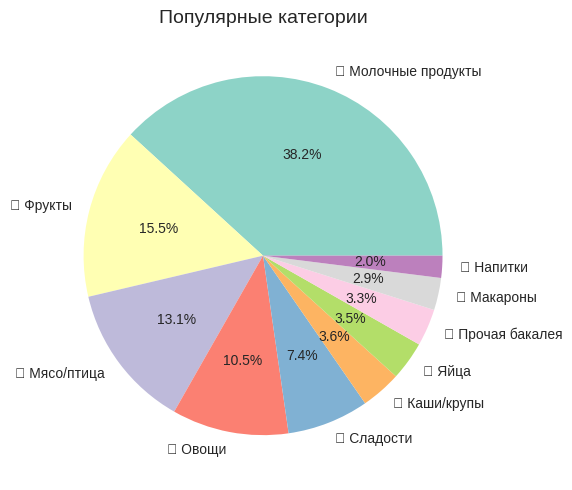

In [104]:
# Топ-10 товаров по сумме
print("\n" + "="*60)
print("🏆 ТОП-10 ТОВАРОВ ПО СУММЕ ПОКУПОК")
print("="*60)
top_products = df.groupby('Товар')['Итого (BYN)'].sum().sort_values(ascending=False).head(10)
for i, (product, total) in enumerate(top_products.items(), 1):
    print(f"{i:2}. {product[:50]:50} {total:8.2f} BYN")

# Топ-10 товаров по частоте
print("\n" + "="*60)
print("🏆 ТОП-10 ТОВАРОВ ПО ЧАСТОТЕ ПОКУПОК")
print("="*60)
top_frequent = df['Товар'].value_counts().head(10)
for i, (product, count) in enumerate(top_frequent.items(), 1):
    print(f"{i:2}. {product[:50]:50} {count:3} раз(а)")

# По категориям
print("\n" + "="*60)
print("📂 ПОПУЛЯРНОСТЬ КАТЕГОРИЙ")
print("="*60)
category_sum = df.groupby('Категория')['Итого (BYN)'].sum().sort_values(ascending=False).head(10)
category_count = df['Категория'].value_counts()

for cat in category_sum.index:
    print(f"{cat:12} | Сумма: {category_sum[cat]:7.2f} BYN | Кол-во: {category_count[cat]:3} шт | Доля: {category_sum[cat]/df['Итого (BYN)'].sum()*100:.1f}%")


colors = plt.cm.Set3(range(len(category_count)))

plt.figure(figsize=(12, 5))
plt.pie(category_sum, labels=category_sum.index, autopct='%1.1f%%', colors=colors)
plt.title('Популярные категории', fontsize=14)
plt.tight_layout()
plt.savefig('./readme_images/popular_categories.png')
plt.show()




⏰ АНАЛИЗ ПО ЧАСАМ

📊 По часам:
     Сумма_покупок  Средняя_цена_товара  Кол-во_чеков
Час                                                  
6           639.57                 7.71             3
7           634.05                 6.75             3
8           861.66                 7.12             4
9           395.57                 3.63             3
10          218.29                 3.36             3
11          704.53                 3.63            10
12          169.92                 2.74             3
15          202.74                 3.38             3
17          291.75                 5.95             2
18         1029.10                 6.31             7
19         2697.04                 6.93            15
20          593.90                 5.55             4
21         1717.86                 7.34             9
22         1006.74                 7.04             5
23         1912.89                 6.38            12


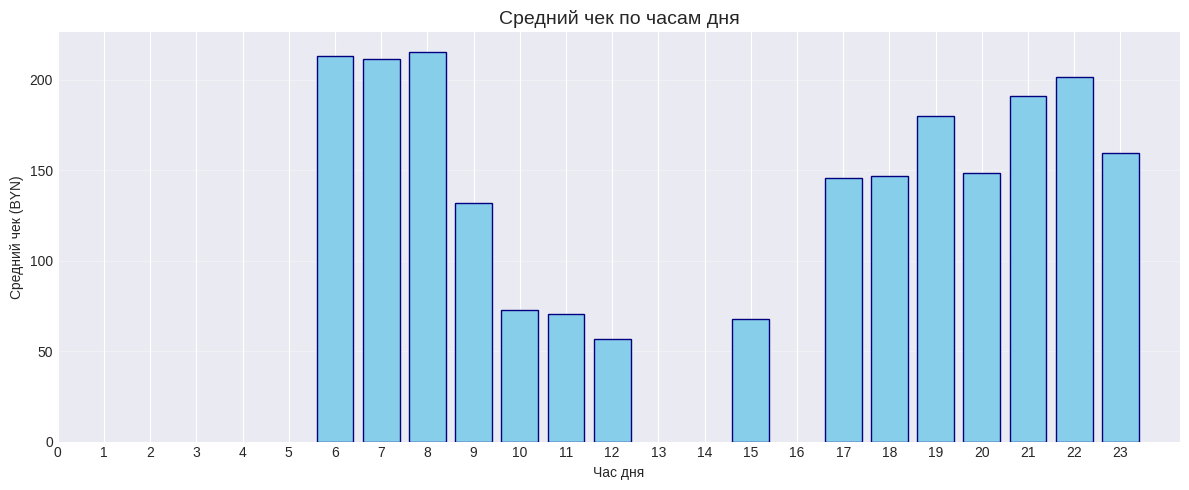


📅 АНАЛИЗ ПО ДНЯМ НЕДЕЛИ
Monday     | Чеков: 12 | Общая сумма: 1347.88 BYN | Средний чек: 112.32 BYN
Tuesday    | Чеков: 15 | Общая сумма: 2604.81 BYN | Средний чек: 173.65 BYN
Wednesday  | Чеков: 11 | Общая сумма: 1872.82 BYN | Средний чек: 170.26 BYN
Thursday   | Чеков: 12 | Общая сумма: 1928.61 BYN | Средний чек: 160.72 BYN
Friday     | Чеков: 14 | Общая сумма: 2099.14 BYN | Средний чек: 149.94 BYN
Saturday   | Чеков: 14 | Общая сумма: 2036.97 BYN | Средний чек: 145.50 BYN
Sunday     | Чеков:  8 | Общая сумма: 1185.38 BYN | Средний чек: 148.17 BYN


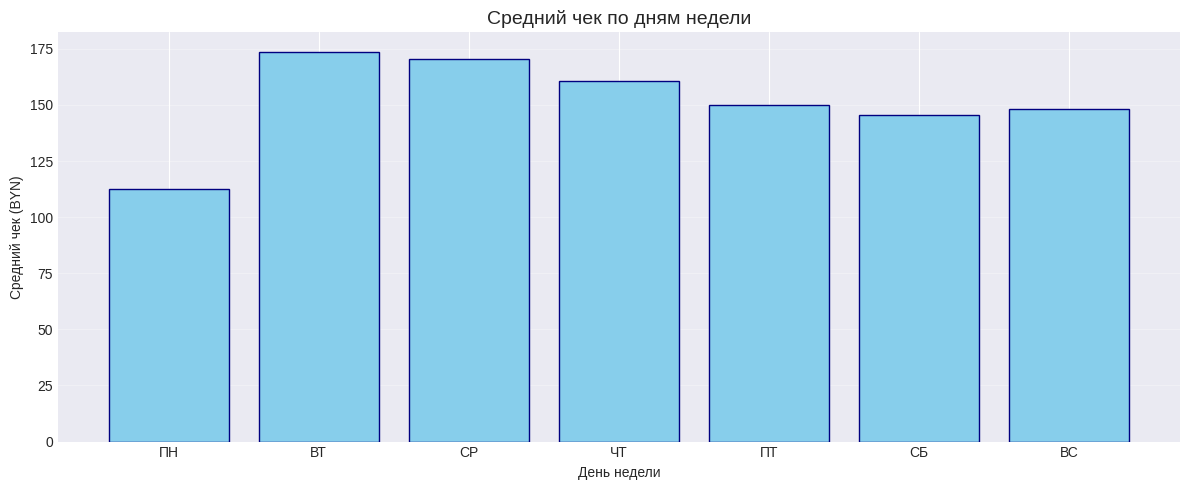

In [105]:
print("\n" + "="*60)
print("⏰ АНАЛИЗ ПО ЧАСАМ")
print("="*60)

hourly_stats = df.groupby('Час').agg({
    'Итого (BYN)': ['sum', 'mean'],
    'Файл': 'nunique'
}).round(2)
hourly_stats.columns = ['Сумма_покупок', 'Средняя_цена_товара', 'Кол-во_чеков']

print("\n📊 По часам:")
print(hourly_stats)

# График: средний чек по часам
plt.figure(figsize=(12, 5))
hourly_cheque = cheque_stats.groupby('Час')['Сумма чека (расч)'].mean()
plt.bar(hourly_cheque.index, hourly_cheque.values, color='skyblue', edgecolor='navy')
plt.title('Средний чек по часам дня', fontsize=14)
plt.xlabel('Час дня')
plt.ylabel('Средний чек (BYN)')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# По дням недели
print("\n" + "="*60)
print("📅 АНАЛИЗ ПО ДНЯМ НЕДЕЛИ")
print("="*60)


days_order_ru = ['ПН', 'ВТ', 'СР', 'ЧТ', 'ПТ', 'СБ', 'ВС']
days_map = {
    'Monday': 'ПН', 'Tuesday': 'ВТ', 'Wednesday': 'СР',
    'Thursday': 'ЧТ', 'Friday': 'ПТ', 'Saturday': 'СБ', 'Sunday': 'ВС'
}

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_stats = df.groupby('День недели_текст').agg({
    'Итого (BYN)': 'sum',
    'Файл': 'nunique'
}).reindex(days_order)

for day in days_order:
    if day in daily_stats.index:
        avg_cheque = daily_stats.loc[day, 'Итого (BYN)'] / daily_stats.loc[day, 'Файл']
        print(f"{day:10} | Чеков: {daily_stats.loc[day, 'Файл']:2} | Общая сумма: {daily_stats.loc[day, 'Итого (BYN)']:7.2f} BYN | Средний чек: {avg_cheque:.2f} BYN")


# График: средний чек по часам
plt.figure(figsize=(12, 5))
hourly_cheque = cheque_stats.groupby('День недели_текст')['Сумма чека (расч)'].mean()
hourly_cheque_sorted = hourly_cheque.reindex(days_order).rename(days_map)

plt.bar(hourly_cheque_sorted.index, hourly_cheque_sorted.values, color='skyblue', edgecolor='navy')
plt.title('Средний чек по дням недели', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Средний чек (BYN)')
plt.xticks(range(0, 7))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()        


🌸 СЕЗОННЫЙ АНАЛИЗ
12
       Итого (BYN)  Файл  Товар
Месяц                          
1          1527.84     8    223
2           956.22     5    133
3          1101.60    12    234
4          1546.65    13    314
5          1399.24    13    325
6           838.43     4    124
7           676.47     4     98
8           598.11     4     93
9           757.52     4    100
10          682.75     4     94
11         1168.11     6    177
12         1822.67     9    258


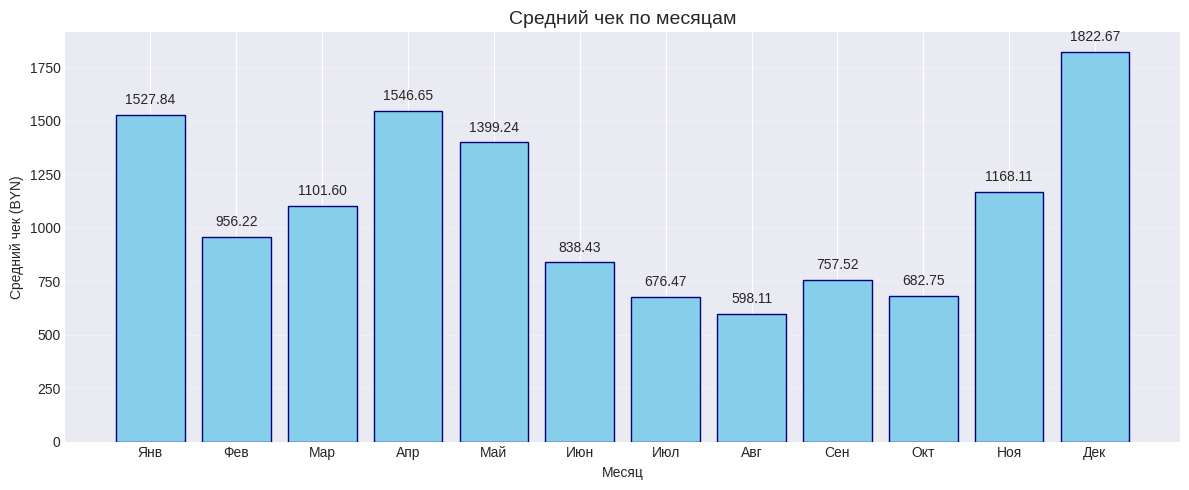

Янв  | Сумма: 1527.84 BYN | Чеков:  8 | Товаров: 223
Фев  | Сумма:  956.22 BYN | Чеков:  5 | Товаров: 133
Мар  | Сумма: 1101.60 BYN | Чеков: 12 | Товаров: 234
Апр  | Сумма: 1546.65 BYN | Чеков: 13 | Товаров: 314
Май  | Сумма: 1399.24 BYN | Чеков: 13 | Товаров: 325
Июн  | Сумма:  838.43 BYN | Чеков:  4 | Товаров: 124
Июл  | Сумма:  676.47 BYN | Чеков:  4 | Товаров: 98
Авг  | Сумма:  598.11 BYN | Чеков:  4 | Товаров: 93
Сен  | Сумма:  757.52 BYN | Чеков:  4 | Товаров: 100
Окт  | Сумма:  682.75 BYN | Чеков:  4 | Товаров: 94
Ноя  | Сумма: 1168.11 BYN | Чеков:  6 | Товаров: 177
Дек  | Сумма: 1822.67 BYN | Чеков:  9 | Товаров: 258


In [106]:
print("\n" + "="*60)
print("🌸 СЕЗОННЫЙ АНАЛИЗ")
print("="*60)

# Месячная динамика
monthly = df.groupby('Месяц').agg({
    'Итого (BYN)': 'sum',
    'Файл': 'nunique',
    'Товар': 'count'
})

print(len(monthly))
print(monthly.head(n=20))

months_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

plt.figure(figsize=(12, 5))
plt.bar(monthly.index, monthly['Итого (BYN)'], color='skyblue', edgecolor='navy')
plt.title('Средний чек по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Средний чек (BYN)')
plt.xticks(range(1, len(monthly)+1), months_names)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Добавляем значения на столбцы
for i, value in enumerate(monthly['Итого (BYN)']):
    plt.text(i + 1, value + 50, f'{value:.2f}', ha='center', fontsize=10)
plt.show()


for month in monthly.index:
    if month <= len(months_names):
        print(f"{months_names[month-1]:4} | Сумма: {monthly.loc[month, 'Итого (BYN)']:7.2f} BYN | Чеков: {monthly.loc[month, 'Файл']:2} | Товаров: {monthly.loc[month, 'Товар']:2}")


In [107]:
print("\n" + "="*60)
print("🔄 ПОСТОЯННЫЕ ПОКУПКИ (в >40% чеков)")
print("="*60)

total_cheques = df['Файл'].nunique()
product_frequency = df.groupby('Товар')['Файл'].nunique().sort_values(ascending=False)
constant_products = product_frequency[product_frequency / total_cheques > 0.4]

for product, freq in constant_products.head(10).items():
    percentage = (freq / total_cheques) * 100
    print(f"   {product[:45]:45} | {percentage:.0f}% чеков ({freq}/{total_cheques})")


🔄 ПОСТОЯННЫЕ ПОКУПКИ (в >40% чеков)
   Молоко"ЗДРАВУШКА"3.2%(стер,ТБА)1л             | 49% чеков (42/86)
   Молоко"ЗДРАВУШКА"3.4- 6%(паст,ПЭТ)0.93 л      | 45% чеков (39/86)



📊 АНАЛИЗ ПРИСУТСТВИЯ КАТЕГОРИЙ В ЧЕКАХ

📋 Всего чеков: 86

🏆 КАТЕГОРИИ ПО ПРОЦЕНТУ ПРИСУТСТВИЯ В ЧЕКАХ:
-------------------------------------------------------
🥛 Молочные продукты  |  96.5% (83/86) ███████████████████
🍎 Фрукты             |  86.0% (74/86) █████████████████
🥬 Овощи              |  83.7% (72/86) ████████████████
🍰 Сладости           |  77.9% (67/86) ███████████████
🍖 Мясо/птица         |  73.3% (63/86) ██████████████
🍞 Хлеб/выпечка       |  72.1% (62/86) ██████████████
🛒 Прочая бакалея     |  52.3% (45/86) ██████████
🥚 Яйца               |  51.2% (44/86) ██████████
🥣 Каши/крупы         |  44.2% (38/86) ████████
☕ Напитки            |  43.0% (37/86) ████████
🧹 Бытовая химия      |  37.2% (32/86) ███████
🍝 Макароны           |  36.0% (31/86) ███████
👶 Детские товары     |  17.4% (15/86) ███
🐟 Рыба/морепродукты  |  15.1% (13/86) ███
🥜 Орехи/снеки        |  14.0% (12/86) ██
📦 Прочее             |   1.2% (1/86) 


/tmp/ipykernel_18125/1635131824.py:56: UserWarning: Glyph 129371 (\N{GLASS OF MILK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/1635131824.py:56: UserWarning: Glyph 127822 (\N{RED APPLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/1635131824.py:56: UserWarning: Glyph 129388 (\N{LEAFY GREEN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/1635131824.py:56: UserWarning: Glyph 127856 (\N{SHORTCAKE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/1635131824.py:56: UserWarning: Glyph 127830 (\N{MEAT ON BONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/1635131824.py:56: UserWarning: Glyph 127838 (\N{BREAD}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/1635131824.py:56: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipy

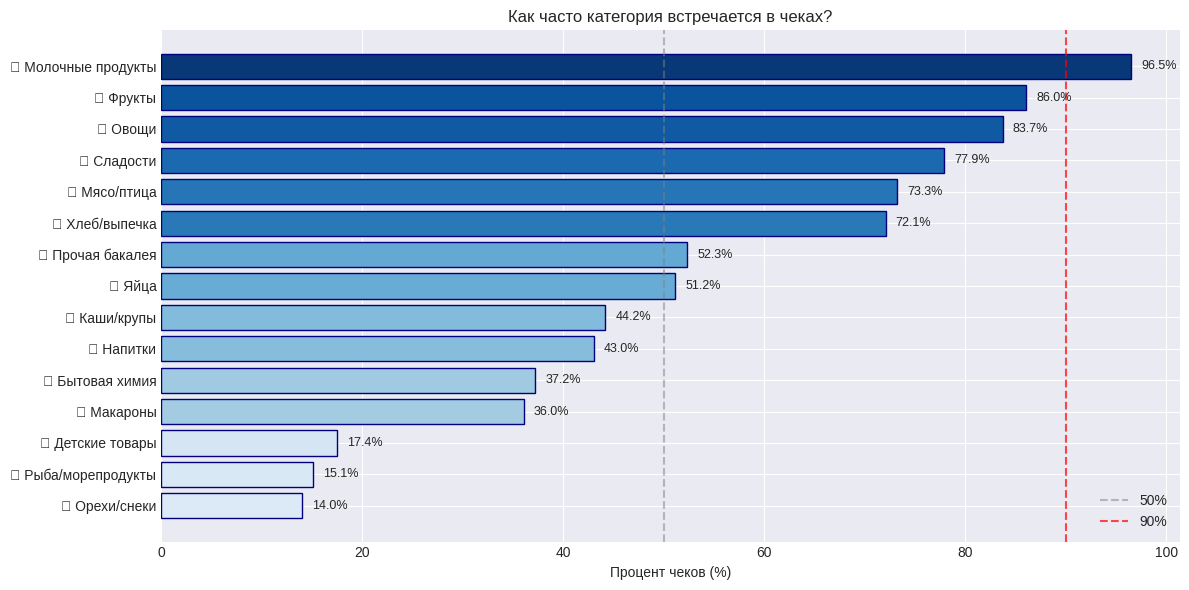


📊 КРАТКАЯ СВОДКА:
   🥇 Самая частотная: 🥛 Молочные продукты — 96.5%
   🥈 Вторая: 🍎 Фрукты — 86.0%
   🥉 Третья: 🥬 Овощи — 83.7%


In [108]:
# %%
print("\n" + "="*60)
print("📊 АНАЛИЗ ПРИСУТСТВИЯ КАТЕГОРИЙ В ЧЕКАХ")
print("="*60)

# 1. Для каждого чека отмечаем, какие категории в нём были
# (убираем дубликаты — один чек + одна категория = 1, даже если товаров несколько)
cheque_categories = df.groupby(['Файл', 'Категория']).size().reset_index(name='количество_товаров')
# groupby сам убирает дубликаты, это нормально

# 2. Считаем, в скольких чеках присутствует каждая категория
category_cheque_count = cheque_categories.groupby('Категория')['Файл'].nunique().sort_values(ascending=False)

# 3. Общее количество чеков
total_cheques = df['Файл'].nunique()

# 4. Создаём DataFrame с результатами
category_coverage = pd.DataFrame({
    'Категория': category_cheque_count.index,
    'Количество_чеков': category_cheque_count.values,
    'Процент_чеков': (category_cheque_count.values / total_cheques) * 100
}).reset_index(drop=True)

# 5. Выводим результаты
print(f"\n📋 Всего чеков: {total_cheques}\n")
print("🏆 КАТЕГОРИИ ПО ПРОЦЕНТУ ПРИСУТСТВИЯ В ЧЕКАХ:")
print("-" * 55)

for _, row in category_coverage.iterrows():
    cat = row['Категория']
    pct = row['Процент_чеков']
    freq = row['Количество_чеков']
    # Визуальная шкала (1 символ = 5%)
    bars = "█" * int(pct / 5)
    print(f"{cat:20} | {pct:5.1f}% ({freq}/{total_cheques}) {bars}")

# 6. Визуализация
plt.figure(figsize=(12, 6))
# Берём топ-15 для наглядности
top_categories = category_coverage.head(15)
colors = plt.cm.Blues(top_categories['Процент_чеков'] / 100)

plt.barh(range(len(top_categories)), top_categories['Процент_чеков'], color=colors, edgecolor='navy')
plt.yticks(range(len(top_categories)), top_categories['Категория'])
plt.xlabel('Процент чеков (%)')
plt.title('Как часто категория встречается в чеках?')
plt.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='50%')
plt.axvline(x=90, color='red', linestyle='--', alpha=0.7, label='90%')
plt.legend()

# Добавляем значения
for i, (_, row) in enumerate(top_categories.iterrows()):
    plt.text(row['Процент_чеков'] + 1, i, f"{row['Процент_чеков']:.1f}%", va='center', fontsize=9)

plt.gca().invert_yaxis()  # Чтобы самая частотная была сверху
plt.tight_layout()
plt.savefig('./readme_images/category_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

# 7. Краткая сводка
print("\n📊 КРАТКАЯ СВОДКА:")
print(f"   🥇 Самая частотная: {category_coverage.iloc[0]['Категория']} — {category_coverage.iloc[0]['Процент_чеков']:.1f}%")
print(f"   🥈 Вторая: {category_coverage.iloc[1]['Категория']} — {category_coverage.iloc[1]['Процент_чеков']:.1f}%")
print(f"   🥉 Третья: {category_coverage.iloc[2]['Категория']} — {category_coverage.iloc[2]['Процент_чеков']:.1f}%")

In [ ]:
# # Проверка: какие товары не попали в категории
# uncategorized = df[df['Категория'] == '❓ Неизвестная категория']['Товар'].unique()
# print(f"Некатегоризировано: {len(uncategorized)} товаров")
# for item in uncategorized[:20]:
#     print(f"  - {item}")

Некатегоризировано: 0 товаров
